In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
image1_path = r"N:\PROJ_TPE\chessboard\20260807_bw.bmp" #INPUT BLACK-WHITE IMAGE
image2_path = r"N:\PROJ_TPE\chessboard\20260807_color.bmp" #INPUT COLOR IMAGE

# === Load images ===
img1 = cv2.imread(image1_path)[:,:,0]
img2 = cv2.imread(image2_path)[:,:,0]
img2 = cv2.flip(img2, 1) #flip color image

#binarize the images (not necessarily better than gray, use whatever works)
thresh1, bw1 = cv2.threshold(img1,0,255,cv2.THRESH_OTSU)
thresh2, bw2 = cv2.threshold(img2,0,255,cv2.THRESH_OTSU)


True True


Text(0.5, 1.0, 'Corners in Image 2')

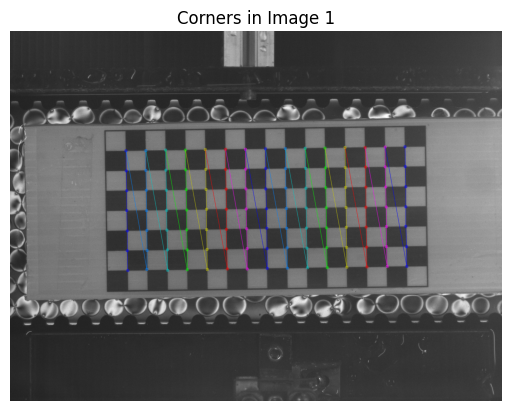

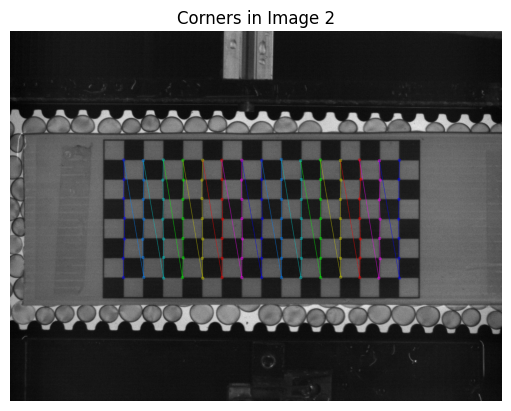

In [2]:

# === Find checkerboard corners ===

# termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

ret1, corners1 = cv2.findChessboardCorners(img1, (7,15), None)
ret2, corners2 = cv2.findChessboardCorners(bw2, (7,15), None)
print(ret1, ret2)


############## reverse the order of points in corners2 if needed ###################
#corners2 = np.concatenate([corners2[i::15] for i in [14,13,12,11,10,9,8,7,6,5,4,3,2,1,0]], axis=0)
#corners2 = np.flip(corners2, axis=0)

#plot points in corners1
plt.figure()
img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
plt.imshow(cv2.drawChessboardCorners(img1_color, (7,15), corners1, ret1))
plt.axis('off')
plt.title("Corners in Image 1")


plt.figure()
img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
plt.imshow(cv2.drawChessboardCorners(img2_color, (7,15), corners2, ret2))
plt.axis('off')
plt.title("Corners in Image 2")

## Add a new cell for every new calibration, with the date noted on top

20260807

In [3]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)

#save the homography matrix to a file
np.save(r"calibration_matrix/20260807.npy", H)


20260803

In [4]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00895819e+00,  1.99645536e-02, -7.66137225e+00],
       [-1.70880077e-02,  1.01567031e+00, -3.74078920e+01],
       [-2.28032463e-06,  5.40377039e-07,  1.00000000e+00]])

20260724

In [6]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00810648e+00,  2.07619484e-02, -8.25786422e+00],
       [-1.79280610e-02,  1.01567592e+00, -3.54917920e+01],
       [-2.94348094e-06,  9.60910808e-07,  1.00000000e+00]])

20260717

In [3]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00859327e+00,  2.09680332e-02, -7.31321544e+00],
       [-1.77177524e-02,  1.01612567e+00, -3.76854660e+01],
       [-2.91216790e-06,  1.31392816e-06,  1.00000000e+00]])

20260602

In [4]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.01105619e+00,  2.08816758e-02, -8.83887890e+00],
       [-1.71836298e-02,  1.01745043e+00, -4.08410341e+01],
       [-1.26655447e-06,  1.01800064e-06,  1.00000000e+00]])

20260529

In [4]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.01091010e+00,  2.18656475e-02, -1.13597485e+01],
       [-1.75312312e-02,  1.01766535e+00, -4.21511105e+01],
       [-1.52393531e-06,  1.34024721e-06,  1.00000000e+00]])

20260518

In [21]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00705242e+00,  2.12358461e-02, -3.07876734e+00],
       [-1.92355106e-02,  1.01482353e+00, -3.99864701e+01],
       [-3.34090386e-06,  6.21694738e-07,  1.00000000e+00]])

20250512

In [4]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00709337e+00,  2.06229783e-02, -5.31144010e-01],
       [-1.87725215e-02,  1.01469585e+00, -4.06295770e+01],
       [-3.28222913e-06,  4.57406797e-07,  1.00000000e+00]])

20250511

In [4]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00897850e+00,  2.09385077e-02, -1.22728762e+00],
       [-1.80085815e-02,  1.01619232e+00, -4.11885450e+01],
       [-2.43424373e-06,  8.55305735e-07,  1.00000000e+00]])

20260506

In [5]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00709163e+00,  2.01940780e-02, -1.42063713e+00],
       [-1.81984493e-02,  1.01468029e+00, -3.83163172e+01],
       [-3.17462188e-06,  4.07314753e-07,  1.00000000e+00]])

20260414

In [11]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00494159e+00,  2.04956421e-02, -1.06058326e+00],
       [-1.91282504e-02,  1.01391972e+00, -3.65225729e+01],
       [-4.45217427e-06,  9.05846769e-07,  1.00000000e+00]])

20260327

In [6]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00731645e+00,  1.98218406e-02, -6.43662115e+00],
       [-1.82286737e-02,  1.01486389e+00, -3.10338467e+01],
       [-3.23006674e-06,  4.43461020e-07,  1.00000000e+00]])

20260324

In [6]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00776544e+00,  1.93259316e-02, -6.88124044e+00],
       [-1.74921356e-02,  1.01437712e+00, -2.97281053e+01],
       [-2.77621768e-06, -7.22953359e-08,  1.00000000e+00]])

20260318

In [9]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00804856e+00,  2.12924884e-02, -1.24548606e+01],
       [-1.76301434e-02,  1.01725423e+00, -2.75244170e+01],
       [-3.56230187e-06,  2.25518384e-06,  1.00000000e+00]])

20260304_2

In [55]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00654889e+00,  1.96540570e-02, -6.93742929e+00],
       [-1.82351292e-02,  1.01471559e+00, -2.83423136e+01],
       [-3.73774363e-06,  6.86833926e-07,  1.00000000e+00]])

20260304

In [36]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00702244e+00,  1.90124948e-02, -7.11557960e+00],
       [-1.76727023e-02,  1.01443150e+00, -2.78178255e+01],
       [-2.91998133e-06, -2.34125950e-07,  1.00000000e+00]])

20260302

In [24]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.01015866e+00,  2.00877449e-02, -5.19372650e+00],
       [-1.65445867e-02,  1.01724996e+00, -3.24054735e+01],
       [-1.81315104e-06,  1.03633837e-06,  1.00000000e+00]])

20260122

In [3]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00847109e+00,  1.96903443e-02, -1.54332807e+01],
       [-1.68872158e-02,  1.01773292e+00, -2.19123604e+01],
       [-3.15305787e-06,  1.27538375e-06,  1.00000000e+00]])

20251223

In [3]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00986534e+00,  2.01091183e-02, -9.53323848e+00],
       [-1.73642316e-02,  1.01848045e+00, -2.63148295e+01],
       [-2.22558459e-06,  2.31731578e-06,  1.00000000e+00]])

20251127

In [24]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.00951540e+00,  2.22524727e-02, -1.51024319e+01],
       [-1.73191010e-02,  1.01998200e+00, -2.47131352e+01],
       [-3.55676724e-06,  3.77249310e-06,  1.00000000e+00]])

20251008

In [18]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 1.01602968e+00,  1.79290181e-02, -1.31703458e+01],
       [-1.33983308e-02,  1.01873853e+00, -3.12472372e+01],
       [ 3.11282180e-06, -1.13478290e-06,  1.00000000e+00]])

20250918

In [26]:
# Refine corner locations for sub-pixel accuracy
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Ensure corners are in the correct format (single-channel, floating-point)
corners1 = corners1.astype(np.float32)
corners2 = corners2.astype(np.float32)

corners1 = cv2.cornerSubPix(img1, corners1, (11, 11), (-1, -1), criteria)
corners2 = cv2.cornerSubPix(img2, corners2, (11, 11), (-1, -1), criteria)

# Compute homography from cam2 to cam1
H, mask = cv2.findHomography(corners2, corners1, cv2.RANSAC)
H


array([[ 9.66563925e-01,  4.69980014e-03,  3.25848181e+01],
       [-2.45695147e-03,  9.68120605e-01,  4.88898748e+00],
       [ 9.41078593e-08, -2.20576245e-07,  1.00000000e+00]])